In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

In [17]:
df = pd.read_csv("/content/heart_attack_dataset.csv")
df['Heart_Attack_Risk'] = np.random.randint(0, 2, size=len(df)) # Add a dummy target column

print(df.head())
print(df.shape)

   Gender  Age  Blood Pressure (mmHg)  Cholesterol (mg/dL) Has Diabetes  \
0    Male   70                    181                  262           No   
1  Female   55                    103                  253          Yes   
2    Male   42                     95                  295          Yes   
3    Male   84                    106                  270           No   
4    Male   86                    187                  296          Yes   

  Smoking Status   Chest Pain Type                            Treatment  \
0          Never    Typical Angina                    Lifestyle Changes   
1          Never   Atypical Angina                          Angioplasty   
2        Current    Typical Angina                          Angioplasty   
3          Never   Atypical Angina  Coronary Artery Bypass Graft (CABG)   
4        Current  Non-anginal Pain                           Medication   

   Heart_Attack_Risk  
0                  1  
1                  1  
2                  1  
3     

In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Gender                 1000 non-null   object
 1   Age                    1000 non-null   int64 
 2   Blood Pressure (mmHg)  1000 non-null   int64 
 3   Cholesterol (mg/dL)    1000 non-null   int64 
 4   Has Diabetes           1000 non-null   object
 5   Smoking Status         1000 non-null   object
 6   Chest Pain Type        1000 non-null   object
 7   Treatment              1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:
Gender                   0
Age                      0
Blood Pressure (mmHg)    0
Cholesterol (mg/dL)      0
Has Diabetes             0
Smoking Status           0
Chest Pain Type          0
Treatment                0
dtype: int64

Statistical Summary:
               Age  Blood Pressure (mmHg)  Cholesterol (mg/dL

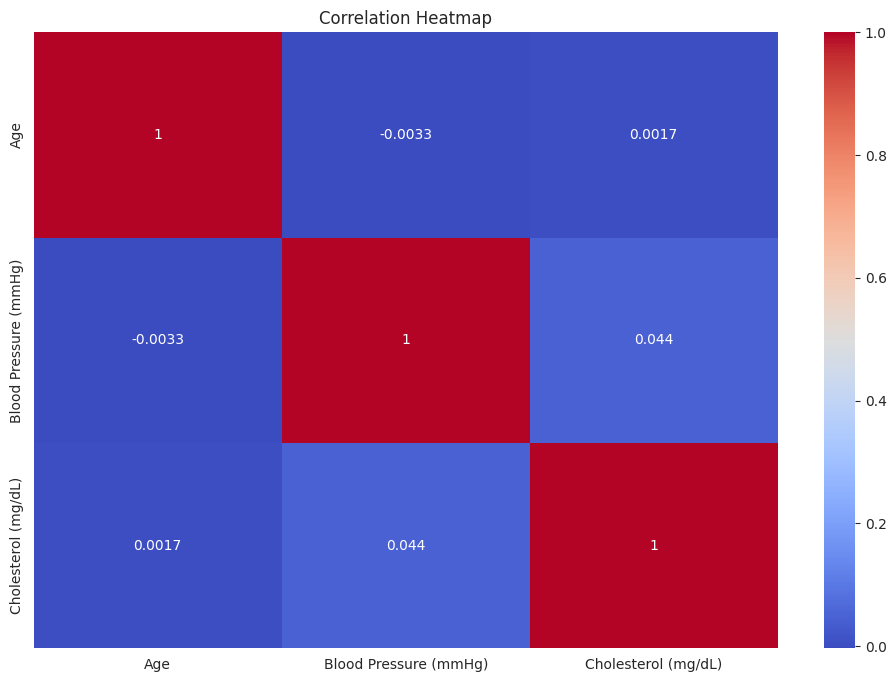

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

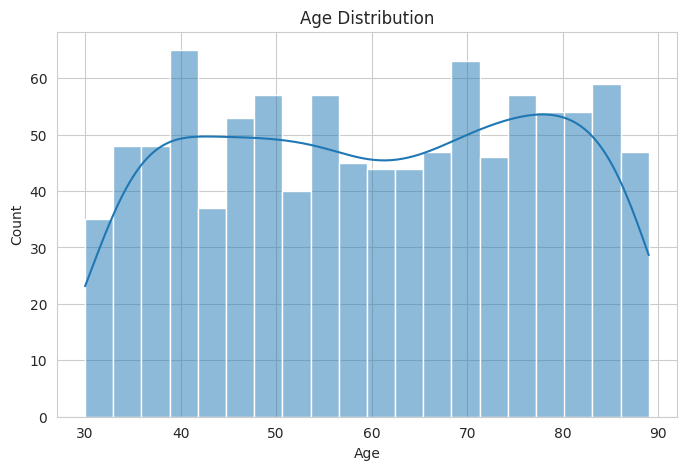

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

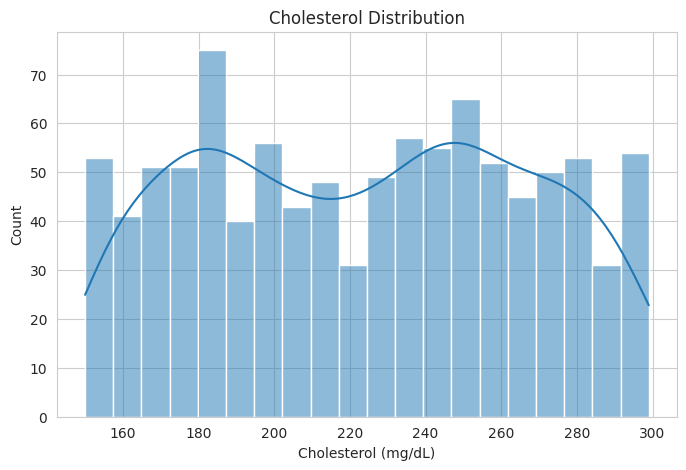

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol (mg/dL)'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

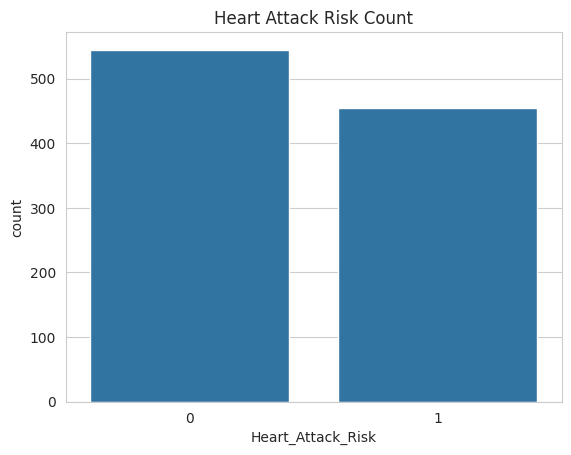

In [18]:
sns.countplot(x='Heart_Attack_Risk', data=df)
plt.title("Heart Attack Risk Count")
plt.show()

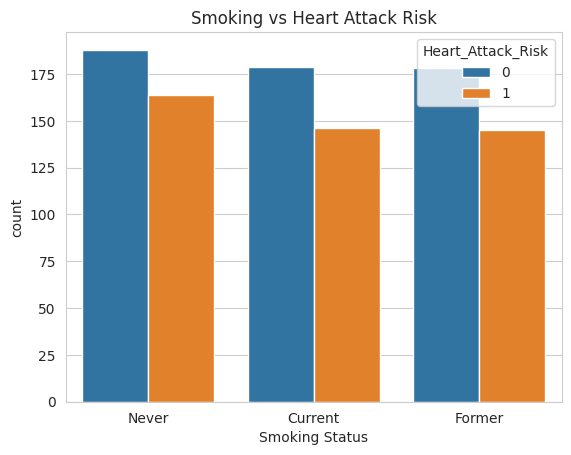

In [19]:
sns.countplot(x='Smoking Status', hue='Heart_Attack_Risk', data=df)
plt.title("Smoking vs Heart Attack Risk")
plt.show()

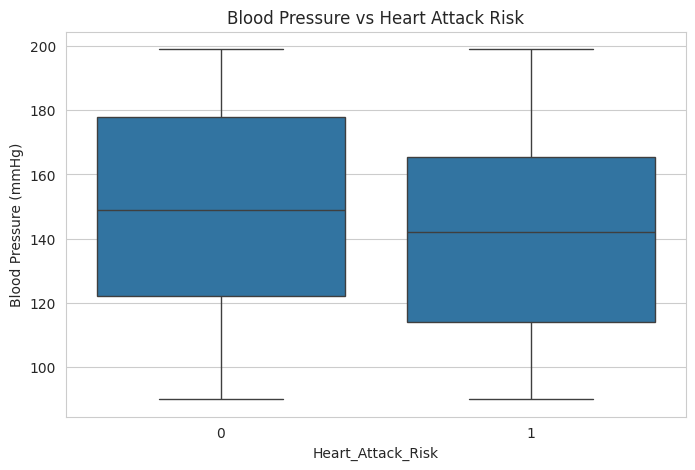

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Heart_Attack_Risk', y='Blood Pressure (mmHg)', data=df)
plt.title("Blood Pressure vs Heart Attack Risk")
plt.show()

In [23]:
# One-hot encode categorical features
X = pd.get_dummies(df.drop('Heart_Attack_Risk', axis=1), drop_first=True)
y = df['Heart_Attack_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
# One-hot encode categorical features
X = pd.get_dummies(df.drop('Heart_Attack_Risk', axis=1), drop_first=True)
y = df['Heart_Attack_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.55

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.68      0.63       113
           1       0.48      0.38      0.42        87

    accuracy                           0.55       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.54      0.55      0.54       200


Confusion Matrix:
[[77 36]
 [54 33]]


                                          Feature  Importance
7                 Chest Pain Type_Atypical Angina    0.092348
11                    Treatment_Lifestyle Changes    0.082913
6                            Smoking Status_Never    0.081380
5                           Smoking Status_Former    0.065050
12                           Treatment_Medication    0.045346
10  Treatment_Coronary Artery Bypass Graft (CABG)    0.032684
4                                Has Diabetes_Yes    0.032514
8                Chest Pain Type_Non-anginal Pain    0.017799
9                  Chest Pain Type_Typical Angina   -0.039767
0                                             Age   -0.046880
3                                     Gender_Male   -0.052937
2                             Cholesterol (mg/dL)   -0.136418
1                           Blood Pressure (mmHg)   -0.225315


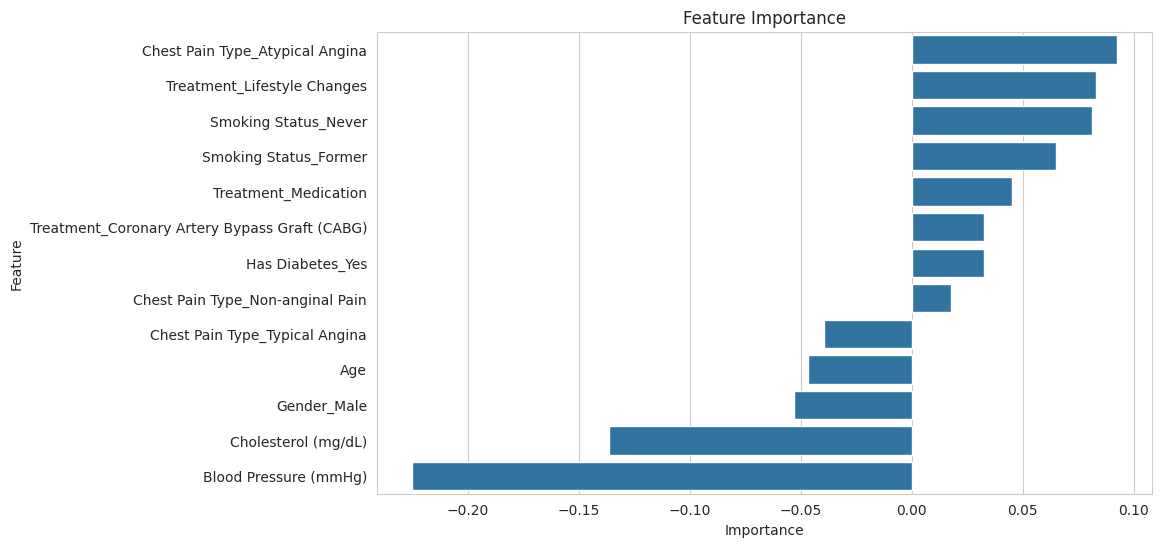

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()